<a href="https://colab.research.google.com/github/brandonrugelesl/analysis_everpeak/blob/main/Ejercicio_Sprint07_Webinar21_Practica_copia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 7 · Clase práctica comprimida · Student Version · Proyecto guiado con automatización básica

**Duración:** 80 minutos  
**Modalidad:** Práctica guiada  
**Nivel:** Introductorio  

Esta práctica consolida los temas de preparación de datos, exploración, gráficos, outliers, segmentación y GitHub. La diferencia principal frente a la versión anterior es que ahora se incluye explícitamente **automatización con iterables, ciclos `for`, ciclos `while` y mini-funciones**.


## Modo estudiante

Esta versión está pensada para trabajar durante la sesión.

- Lee cada consigna antes de escribir código.
- Usa las pistas si te bloqueas.
- Completa las celdas marcadas con `TODO`.
- Algunas celdas tienen código comentado para que lo tomes como guía.
- No necesitas memorizar todo: enfócate en entender qué problema resuelve cada paso.

### Espacio de notas iniciales

- Concepto nuevo 1:
- Concepto nuevo 2:
- Duda para preguntar:


## Fecha

Completa la información de la sesión:

- **Fecha:**  
- **Instructor/a:**  
- **Duración:** 80 minutos


## Objetivos de la sesión práctica

Al finalizar la sesión, la persona estudiante podrá:

1. Crear un dataset sintético de ventas multicanal.
2. Explorar estructura, tipos de datos y valores nulos.
3. Limpiar valores nulos con reglas simples.
4. Usar listas como iterables para automatizar tareas con `for`.
5. Usar un ciclo `while` con contador para recorrer columnas.
6. Crear mini-funciones para resumir, limpiar y clasificar datos.
7. Detectar outliers con IQR.
8. Crear segmentos de negocio con `.apply()`.
9. Proponer una estructura básica para publicar el análisis en GitHub.


## Metodología de la sesión

Trabajaremos como analistas de una tienda multicanal que vende productos en varios países de Latinoamérica.

El negocio quiere responder preguntas como:

- ¿Qué países y categorías generan más ingresos?
- ¿Qué canales tienen mejores márgenes?
- ¿Hay ventas atípicas?
- ¿Qué segmentos de ventas existen?
- ¿Cómo podemos automatizar revisiones repetitivas?


## Agenda sugerida (80 minutos)

| Tiempo | Bloque | Actividad |
|---:|---|---|
| 0–5 min | Kickoff | Entender el caso de negocio |
| 5–15 min | Dataset | Crear y revisar el dataset |
| 15–25 min | Exploración | `head()`, `shape`, `info()`, nulos |
| 25–38 min | Limpieza | Completar nulos con reglas simples |
| 38–53 min | Automatización | Iterables, `for`, `while` y funciones |
| 53–63 min | Visualización | Gráficos con `.plot()` |
| 63–72 min | Outliers | Regla IQR |
| 72–77 min | Segmentación | Función + `.apply()` |
| 77–80 min | Cierre | GitHub y takeaways |


## Ejercicio 0 · Kickoff del proyecto (5 min)

Caso: una tienda multicanal vende productos por Web, App, tienda física y WhatsApp. Tiene operaciones en Colombia, México, Perú y Chile.

Responde:

1. ¿Qué variable usarías para medir el tamaño de una venta?
el monto total de la venta (valor_total = precio × cantidad). Es más representativo que "cantidad de unidades", porque captura el valor monetario real de la transacción.
2. ¿Qué variable usarías para medir rentabilidad?
el margen (ingreso - costo), idealmente como margen % (margen / ingreso) para poder comparar entre productos o canales sin importar su tamaño.
3. ¿Qué columnas podrían tener valores nulos?
Canal (si hay errores de registro manual, ej. WhatsApp/tienda física)
Costo unitario (a veces no se registra en todos los canales)
Descuento aplicado
ID de cliente / email (compras anónimas en tienda física)
País o ciudad (si el dato de ubicación depende del canal)
Fecha de entrega (aplica solo a Web/App, no a tienda física)
4. ¿Qué tareas te gustaría automatizar para no repetir código?
Limpieza y manejo de nulos (función reutilizable)
Cálculo de métricas derivadas (margen, ticket promedio, % descuento)
Conversión de moneda (COP, MXN, PEN, CLP → una moneda común)
Agregaciones repetitivas por canal/país/mes (groupby)
Generación de gráficos estándar (ventas por canal, tendencia mensual)

## Proyecto práctico: “Ventas Multicanal LATAM”

Usaremos un dataset sintético con 120 ventas. No es un dataset perfecto: tendrá nulos y outliers para practicar.

### Columnas principales

| Columna | Descripción |
|---|---|
| `venta_id` | Identificador de venta |
| `fecha` | Fecha de venta |
| `pais`, `ciudad` | Ubicación |
| `canal` | Web, App, tienda física o WhatsApp |
| `categoria` | Categoría de producto |
| `metodo_pago` | Método de pago |
| `tipo_cliente` | Nuevo o recurrente |
| `ingreso` | Venta después de descuentos |
| `costo_total` | Costo estimado |
| `margen` | Ingreso menos costo |
| `edad_cliente` | Edad del cliente |
| `satisfaccion` | Calificación de 1 a 5 |
| `dias_entrega` | Días de entrega |
| `devolucion` | Sí o No |


## Preparación del entorno y creación del dataset

Ejecuta esta celda antes de iniciar los ejercicios. Esta celda prepara el dataset y no requiere cambios.


In [ ]:
# ============================================================
# Dataset sintético: ventas multicanal
# ============================================================
# Este dataset se crea dentro del notebook para no depender de archivos externos.
# Cada fila representa una venta realizada por un cliente.

import pandas as pd
import random
import matplotlib.pyplot as plt
from IPython.display import display

#pd.set_option('display.max_columns', 30)
#pd.set_option('display.float_format', '{:,.2f}'.format)

# Fijamos una semilla para que todos obtengan los mismos datos.
random.seed(7)

paises = ['Colombia', 'México', 'Perú', 'Chile']
ciudades_por_pais = {
    'Colombia': ['Cali', 'Bogotá', 'Medellín', 'Barranquilla'],
    'México': ['CDMX', 'Guadalajara', 'Monterrey', 'Puebla'],
    'Perú': ['Lima', 'Arequipa', 'Cusco', 'Trujillo'],
    'Chile': ['Santiago', 'Valparaíso', 'Concepción', 'La Serena']
}
canales = ['Web', 'App', 'Tienda física', 'WhatsApp']
categorias = ['Tecnología', 'Hogar', 'Ropa', 'Belleza', 'Deportes']
metodos_pago = ['Tarjeta', 'Transferencia', 'Efectivo', 'Billetera digital']
tipos_cliente = ['Nuevo', 'Recurrente']

ventas = []

for venta_id in range(1, 121):
    pais = random.choice(paises)
    ciudad = random.choice(ciudades_por_pais[pais])
    categoria = random.choice(categorias)
    canal = random.choice(canales)
    metodo_pago = random.choice(metodos_pago)
    tipo_cliente = random.choice(tipos_cliente)

    unidades = random.randint(1, 5)
    precio_unitario = random.choice([25000, 40000, 55000, 80000, 120000, 180000, 250000])
    descuento_pct = random.choice([0, 0.05, 0.10, 0.15, 0.20])

    ingreso = unidades * precio_unitario * (1 - descuento_pct)
    costo_total = ingreso * random.choice([0.45, 0.55, 0.65, 0.75])
    margen = ingreso - costo_total

    satisfaccion = random.choice([1, 2, 3, 4, 5, None])
    edad_cliente = random.choice([19, 22, 25, 28, 31, 35, 39, 42, 47, 52, 58, None])
    dias_entrega = random.choice([1, 2, 3, 4, 5, 6, 7, 10, None])
    devolucion = random.choice(['Sí', 'No', 'No', 'No', 'No'])

    ventas.append({
        'venta_id': venta_id,
        'fecha': pd.Timestamp('2026-01-01') + pd.Timedelta(days=random.randint(0, 89)),
        'pais': pais,
        'ciudad': ciudad,
        'canal': canal,
        'categoria': categoria,
        'metodo_pago': metodo_pago,
        'tipo_cliente': tipo_cliente,
        'unidades': unidades,
        'precio_unitario': precio_unitario,
        'descuento_pct': descuento_pct,
        'ingreso': ingreso,
        'costo_total': costo_total,
        'margen': margen,
        'edad_cliente': edad_cliente,
        'satisfaccion': satisfaccion,
        'dias_entrega': dias_entrega,
        'devolucion': devolucion
    })

df = pd.DataFrame(ventas)

# Agregamos algunos casos extremos de forma intencional para practicar outliers.
#df.loc[condicion, columnas]
#df.loc[4, select]
df.loc[4, 'ingreso'] = 2_800_000
df.loc[4, 'margen'] = 1_250_000
df.loc[18, 'dias_entrega'] = 35
df.loc[50, 'edad_cliente'] = 82
df.loc[90, 'ingreso'] = 1_900_000
df.loc[90, 'margen'] = 850_000

# Guardamos una copia local por si queremos reutilizar el CSV.
df.to_csv('ventas_multicanal_sprint7_intro.csv', index=False)

print('Dataset creado correctamente')
print('Filas y columnas:', df.shape)
display(df.head())


Dataset creado correctamente
Filas y columnas: (120, 18)


,venta_id,fecha,pais,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo_total,margen,edad_cliente,satisfaccion,dias_entrega,devolucion
0,1,2026-01-09,Perú,Arequipa,Web,Belleza,Tarjeta,Nuevo,3,120000,0.0,360000.0,198000.0,162000.0,22.0,1.0,7.0,No
1,2,2026-01-29,México,CDMX,WhatsApp,Deportes,Tarjeta,Nuevo,2,180000,0.2,288000.0,129600.0,158400.0,52.0,5.0,7.0,Sí
2,3,2026-01-13,Colombia,Bogotá,WhatsApp,Ropa,Transferencia,Nuevo,5,55000,0.2,220000.0,121000.0,99000.0,52.0,1.0,4.0,No
3,4,2026-03-31,Colombia,Cali,App,Deportes,Billetera digital,Recurrente,3,80000,0.2,192000.0,144000.0,48000.0,31.0,3.0,4.0,No
4,5,2026-02-13,México,CDMX,Tienda física,Deportes,Billetera digital,Recurrente,4,55000,0.2,2800000.0,79200.0,1250000.0,47.0,1.0,7.0,No


## Ejercicio 1 · Primer vistazo al dataset (10 min)

### Tarea

1. Muestra el tamaño del dataset.
2. Muestra las primeras filas.
3. Lista los nombres de las columnas.
4. Revisa los tipos de datos.

### Pista

Usa `.shape`, `.head()`, `.columns` e `.info()`.


In [ ]:
# TODO - Ejercicio 1: Primer vistazo al dataset

# 1. Muestra el tamaño del dataset
print(df.shape)

# 2. Muestra las primeras filas
display(df.head())

# 3. Muestra la lista de columnas
print(df.columns)

# 4. Revisa la información general del dataset
print(df.info())


(120, 18)


,venta_id,fecha,pais,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo_total,margen,edad_cliente,satisfaccion,dias_entrega,devolucion
0,1,2026-01-09,Perú,Arequipa,Web,Belleza,Tarjeta,Nuevo,3,120000,0.0,360000.0,198000.0,162000.0,22.0,1.0,7.0,No
1,2,2026-01-29,México,CDMX,WhatsApp,Deportes,Tarjeta,Nuevo,2,180000,0.2,288000.0,129600.0,158400.0,52.0,5.0,7.0,Sí
2,3,2026-01-13,Colombia,Bogotá,WhatsApp,Ropa,Transferencia,Nuevo,5,55000,0.2,220000.0,121000.0,99000.0,52.0,1.0,4.0,No
3,4,2026-03-31,Colombia,Cali,App,Deportes,Billetera digital,Recurrente,3,80000,0.2,192000.0,144000.0,48000.0,31.0,3.0,4.0,No
4,5,2026-02-13,México,CDMX,Tienda física,Deportes,Billetera digital,Recurrente,4,55000,0.2,2800000.0,79200.0,1250000.0,47.0,1.0,7.0,No


Index(['venta_id', 'fecha', 'pais', 'ciudad', 'canal', 'categoria',
       'metodo_pago', 'tipo_cliente', 'unidades', 'precio_unitario',
       'descuento_pct', 'ingreso', 'costo_total', 'margen', 'edad_cliente',
       'satisfaccion', 'dias_entrega', 'devolucion'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   venta_id         120 non-null    int64         
 1   fecha            120 non-null    datetime64[ns]
 2   pais             120 non-null    object        
 3   ciudad           120 non-null    object        
 4   canal            120 non-null    object        
 5   categoria        120 non-null    object        
 6   metodo_pago      120 non-null    object        
 7   tipo_cliente     120 non-null    object        
 8   unidades         120 non-null    int64         
 9   precio_unitario  1

## Ejercicio 2 · Identificar valores nulos (7 min)

### Tarea

1. Calcula cuántos nulos hay por columna.
2. Identifica las 3 columnas con más nulos.

### Pista

Usa `.isna().sum()` y luego ordena de mayor a menor con `.sort_values(ascending=False)`.


In [ ]:
# TODO - Ejercicio 2: Identificar valores nulos

# 1. Calcula los nulos por columna
print(df.isna().sum())

# 2. Ordena las columnas de mayor a menor cantidad de nulos
print(df.isna().sum().sort_values(ascending=False))

# 3. Muestra las 3 columnas con más nulos
print(df[['satisfaccion','dias_entrega','edad_cliente']].isna().sum())


venta_id            0
fecha               0
pais                0
ciudad              0
canal               0
categoria           0
metodo_pago         0
tipo_cliente        0
unidades            0
precio_unitario     0
descuento_pct       0
ingreso             0
costo_total         0
margen              0
edad_cliente        9
satisfaccion       21
dias_entrega       12
devolucion          0
dtype: int64
satisfaccion       21
dias_entrega       12
edad_cliente        9
venta_id            0
fecha               0
pais                0
metodo_pago         0
ciudad              0
canal               0
categoria           0
precio_unitario     0
unidades            0
tipo_cliente        0
descuento_pct       0
margen              0
costo_total         0
ingreso             0
devolucion          0
dtype: int64
satisfaccion    21
dias_entrega    12
edad_cliente     9
dtype: int64


## Ejercicio 3 · Limpiar nulos con reglas simples (8 min)

### Tarea

Crea una copia llamada `df_limpio` y completa:

- `edad_cliente` con la mediana.
- `satisfaccion` con la mediana.
- `dias_entrega` con la mediana.

### Pista

Usa `.copy()`, `.median()` y `.fillna()`.


In [ ]:
# TODO - Ejercicio 3: Limpiar nulos con reglas simples

# 1. Crea una copia llamada df_limpio
df1 = df.copy()

# 2. Completa edad_cliente con la mediana
df1['edad_cliente'].fillna(df1['edad_cliente'].median(),inplace = True)

# 3. Completa satisfaccion con la mediana
df1['satisfaccion'].fillna(df1['satisfaccion'].median(),inplace = True)

# 4. Completa dias_entrega con la mediana
df1['dias_entrega'].fillna(df1['dias_entrega'].median(),inplace = True)

# 5. Verifica si todavía quedan nulos
df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   venta_id         120 non-null    int64         
 1   fecha            120 non-null    datetime64[ns]
 2   pais             120 non-null    object        
 3   ciudad           120 non-null    object        
 4   canal            120 non-null    object        
 5   categoria        120 non-null    object        
 6   metodo_pago      120 non-null    object        
 7   tipo_cliente     120 non-null    object        
 8   unidades         120 non-null    int64         
 9   precio_unitario  120 non-null    int64         
 10  descuento_pct    120 non-null    float64       
 11  ingreso          120 non-null    float64       
 12  costo_total      120 non-null    float64       
 13  margen           120 non-null    float64       
 14  edad_cliente     120 non-null    float64  

/tmp/ipykernel_14554/272990212.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['edad_cliente'].fillna(df1['edad_cliente'].median(),inplace = True)
/tmp/ipykernel_14554/272990212.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

## Ejercicio 4 · Automatización con iterables y `for` (10 min)

Un iterable puede ser una lista de columnas. En este ejercicio, usaremos una lista para revisar varias columnas sin copiar y pegar.

### Tarea

1. Crea una lista con columnas numéricas importantes.
2. Usa un ciclo `for` para imprimir promedio, mínimo y máximo de cada columna.

### Pista

La estructura base es:

```python
for columna in lista_columnas:
    print(df_limpio[columna].mean())
```


In [ ]:
# TODO - Ejercicio 4: Automatización con iterables y for

columnas_numericas = [
    'unidades',
    'ingreso',
    'costo_total',
    'margen',
    'edad_cliente',
    'satisfaccion',
    'dias_entrega'
]

# Completa el ciclo for.
# Para cada columna imprime:
# - nombre de la columna
# - promedio
# - mínimo
# - máximo

# for columna in columnas_numericas:
#     ...

for columna in columnas_numericas:
  print(columna,": nombre de columna")
  print(df1[columna].mean(), ": promedio")
  print(df1[columna].min(), ": minimo")
  print(df1[columna].max(), ": maximo")
  print("-------------------------------")

unidades : nombre de columna
3.1333333333333333 : promedio
1 : minimo
5 : maximo
-------------------------------
ingreso : nombre de columna
315306.25 : promedio
20000.0 : minimo
2800000.0 : maximo
-------------------------------
costo_total : nombre de columna
167844.27083333334 : promedio
11250.0 : minimo
890625.0 : maximo
-------------------------------
margen : nombre de columna
126563.64583333333 : promedio
5312.5 : minimo
1250000.0 : maximo
-------------------------------
edad_cliente : nombre de columna
34.516666666666666 : promedio
19.0 : minimo
82.0 : maximo
-------------------------------
satisfaccion : nombre de columna
2.95 : promedio
1.0 : minimo
5.0 : maximo
-------------------------------
dias_entrega : nombre de columna
4.558333333333334 : promedio
1.0 : minimo
35.0 : maximo
-------------------------------


## Ejercicio 5 · Automatización con `while` (8 min)

El ciclo `while` se repite mientras una condición sea verdadera.

### Tarea

Usa `while` para recorrer esta lista de columnas:

```python
columnas_revision = ['ingreso', 'margen', 'dias_entrega']
```

En cada vuelta, imprime el nombre de la columna y su promedio.

### Nota para principiantes

Siempre actualiza el contador dentro del `while`. Si no lo haces, el ciclo puede quedar infinito.


In [ ]:
# TODO - Ejercicio 5: Automatización con while

columnas_revision = ['ingreso', 'margen', 'dias_entrega']

# 1. Crea el contador indice = 0

i = 0

# 2. Crea un while que recorra columnas_revision

while i < len(columnas_revision):
  print(df1[columnas_revision[i]].mean())

  print(columnas_revision[i])
  print("-------------------------------")
  i += 1

# 3. En cada vuelta:
#    - selecciona la columna actual
#    - calcula el promedio
#    - imprime el resultado
#    - aumenta el contador



315306.25
ingreso
-------------------------------
126563.64583333333
margen
-------------------------------
4.558333333333334
dias_entrega
-------------------------------


## Ejercicio 6 · Mini-función para resumir una columna (8 min)

Las funciones ayudan a organizar código y reutilizarlo.

### Tarea

Crea una función llamada `resumir_columna()` que reciba:

- una tabla,
- el nombre de una columna.

La función debe imprimir:

- promedio,
- mediana,
- mínimo,
- máximo.


In [ ]:
# TODO - Ejercicio 6: Mini-función para resumir una columna

def resumir_columna(tabla, columna):
    """
    Recibe:
    - tabla: DataFrame
    - columna: nombre de una columna numérica

    Debe mostrar:
    - promedio
    - mediana
    - mínimo
    - máximo
    """
    # Escribe tu código aquí

    promedio = tabla[columna].mean()
    mediana = tabla[columna].median()
    minimo = tabla[columna].min()
    maximo = tabla[columna].max()


    print("Columna: ", columna)
    print("Promedio:", round(promedio, 2))
    print("Mediana:", round(mediana, 2))
    print("Minimo:", minimo)
    print("Maximo:", maximo)

# Prueba:
resumir_columna(df1, 'unidades')

Columna:  unidades
Promedio: 3.13
Mediana: 3.0
Minimo: 1
Maximo: 5


## Ejercicio 7 · Combinar función + `for` (7 min)

### Tarea

Usa la función `resumir_columna()` dentro de un ciclo `for` para resumir:

- `ingreso`
- `margen`
- `dias_entrega`

Este patrón es una forma simple de automatización.


In [ ]:
# TODO - Ejercicio 7: Combinar función + for

# Usa resumir_columna() dentro de un ciclo for
# para revisar las columnas ingreso, margen y dias_entrega.

for columna in ['ingreso', 'margen', 'dias_entrega']:
  resumir_columna(df1, columna)
  print("---------------------")





Columna:  ingreso
Promedio: 315306.25
Mediana: 185000.0
Minimo: 20000.0
Maximo: 2800000.0
---------------------
Columna:  margen
Promedio: 126563.65
Mediana: 73400.0
Minimo: 5312.5
Maximo: 1250000.0
---------------------
Columna:  dias_entrega
Promedio: 4.56
Mediana: 4.0
Minimo: 1.0
Maximo: 35.0
---------------------


## Ejercicio 8 · GroupBy para responder preguntas de negocio (8 min)

### Tarea

Calcula:

1. Ingreso total por país.
2. Margen promedio por canal.
3. Cantidad de ventas por categoría.

### Pista

Usa `groupby()` con una sola columna para mantenerlo simple.


In [ ]:
# TODO - Ejercicio 8: GroupBy para preguntas de negocio

# 1. Ingreso total por país

print("Ingreso total por pais:", df1.groupby('pais')['ingreso'].sum())
print("-----------------------------------")

# 2. Margen promedio por canal

print("Margen promedio por canal:", df1.groupby('canal')['margen'].mean())
print("-----------------------------------")
# 3. Cantidad de ventas por categoría

print("Cantidad de ventas por categoria:", df1.groupby('categoria')['venta_id'].count())
print("-----------------------------------")


Ingreso total por pais: pais
Chile        8542000.0
Colombia     8933250.0
México      12127000.0
Perú         8234500.0
Name: ingreso, dtype: float64
-----------------------------------
Margen promedio por canal: canal
App              127823.611111
Tienda física    169050.431034
Web              107765.243902
WhatsApp         111436.718750
Name: margen, dtype: float64
-----------------------------------
Cantidad de ventas por categoria: categoria
Belleza       27
Deportes      24
Hogar         26
Ropa          21
Tecnología    22
Name: venta_id, dtype: int64
-----------------------------------


## Ejercicio 9 · Gráficos con `.plot()` (7 min)

### Tarea

1. Crea un gráfico de barras con el ingreso total por país.
2. Crea un histograma de la columna `ingreso`.

### Pista

Usa `.plot(kind='bar')` y `.plot(kind='hist')`.


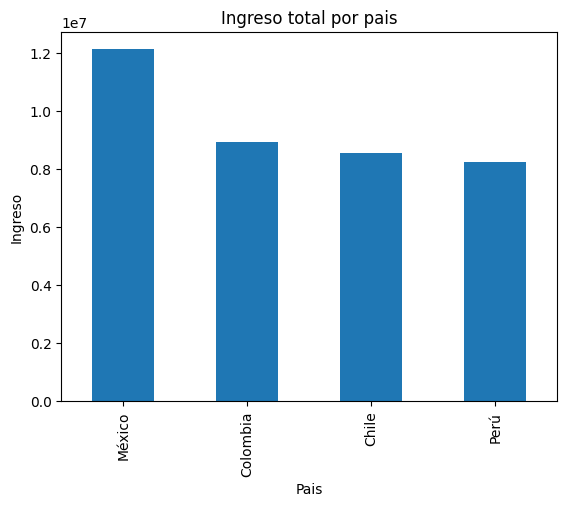

In [ ]:
# TODO - Ejercicio 9A: Gráfico de barras

# 1. Calcula el ingreso total por país

ingreso_por_categoria = df1.groupby('pais')['ingreso'].sum().sort_values(ascending=False)

# 2. Grafica con .plot(kind='bar')

ingreso_por_categoria.plot(kind='bar')
plt.xlabel('Pais')
plt.ylabel('Ingreso')
plt.title('Ingreso total por pais')
plt.show()

# 3. Agrega título, ylabel y muestra la gráfica



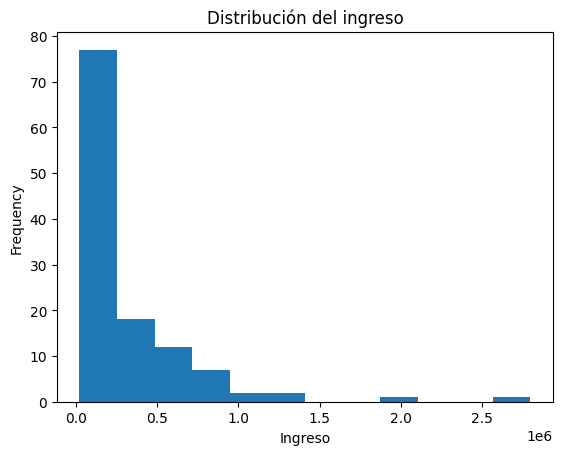

In [ ]:
# TODO - Ejercicio 9B: Histograma del ingreso

# Pista:
df1['ingreso'].plot(kind='hist', bins=12, title='Distribución del ingreso')
plt.xlabel('Ingreso')
plt.show()


## Ejercicio 10 · Mini-función para detectar outliers con IQR (8 min)

### Tarea

Crea una función llamada `obtener_limites_iqr()` que reciba:

- una tabla,
- una columna.

La función debe retornar el límite inferior y superior.


In [ ]:
# TODO - Ejercicio 10: Mini-función para detectar outliers con IQR

def obtener_limites_iqr(tabla, columna):
    """
    Calcula límites de outliers usando IQR.

    Pasos:
    1. q1 = percentil 25
    2. q3 = percentil 75
    3. iqr = q3 - q1
    4. límite inferior = q1 - 1.5 * iqr
    5. límite superior = q3 + 1.5 * iqr
    6. retornar ambos límites
    """
    # Escribe tu código aquí
    pass

# Prueba:
# limite_inf, limite_sup = obtener_limites_iqr(df_limpio, 'ingreso')
# print(limite_inf, limite_sup)


## Ejercicio 11 · Filtrar ventas atípicas (5 min)

### Tarea

Usa los límites del ejercicio anterior para encontrar las ventas cuyo `ingreso` sea mayor al límite superior.


In [ ]:
# TODO - Ejercicio 11: Filtrar ventas atípicas

# Usa el límite superior calculado para filtrar ventas con ingreso alto.

# ventas_atipicas = ...

# Muestra estas columnas:
# venta_id, pais, canal, categoria, ingreso, margen



## Ejercicio 12 · Segmentación con función + `.apply()` (8 min)

### Tarea

Crea una función llamada `clasificar_venta()`:

- Si el ingreso es mayor o igual a 500000: `Venta grande`.
- Si el ingreso es mayor o igual a 150000: `Venta media`.
- En otro caso: `Venta pequeña`.

Luego crea una columna llamada `segmento_venta`.


In [ ]:
# TODO - Ejercicio 12: Segmentación con función + apply

def clasificar_venta(ingreso):
    """
    Reglas sugeridas:
    - Si ingreso >= 500000: Venta grande
    - Si ingreso >= 150000: Venta media
    - Si no: Venta pequeña
    """
    # Escribe tu código aquí
    pass

# Aplica la función a la columna ingreso:
# df_limpio['segmento_venta'] = ...

# Muestra las primeras filas con:
# venta_id, ingreso, segmento_venta


## Ejercicio 13 · Automatizar varios resúmenes finales (7 min)

### Tarea

Crea una función llamada `resumen_por_grupo()` y úsala con un ciclo `for` para generar resúmenes por:

- `pais`
- `canal`
- `categoria`
- `segmento_venta`

Cada resumen debe mostrar:

- cantidad de ventas,
- ingreso total,
- margen promedio.


In [ ]:
# TODO - Ejercicio 13: Automatizar varios resúmenes finales

def resumen_por_grupo(tabla, grupo):
    """
    Crea un resumen agrupado.

    Métricas sugeridas:
    - cantidad de ventas
    - ingreso total
    - margen promedio
    """
    # Escribe tu código aquí
    pass

grupos = ['pais', 'canal', 'categoria', 'segmento_venta']

# Recorre grupos con for y muestra el resumen de cada grupo.
# for grupo in grupos:
#     ...


## Ejercicio 14 · Exportar el dataset limpio (3 min)

Guardar el archivo permite usarlo luego en otro notebook o subirlo a GitHub.


In [ ]:
# TODO - Ejercicio 14: Exportar el dataset limpio

# Exporta df_limpio como CSV.
# Nombre sugerido:
# ventas_multicanal_sprint7_limpio.csv

# Pista:
# df_limpio.to_csv('nombre_archivo.csv', index=False)



## Estructura sugerida para GitHub

```text
ventas-multicanal-latam/
├── data/
│   ├── ventas_multicanal_sprint7_intro.csv
│   └── ventas_multicanal_sprint7_limpio.csv
├── notebooks/
│   └── sprint7_analisis_ventas_multicanal.ipynb
├── images/
│   └── graficos_del_analisis.png
└── README.md
```

### README mínimo

```markdown
# Análisis de ventas multicanal LATAM

## Objetivo
Analizar ventas, márgenes, canales, categorías y posibles valores atípicos.

## Dataset
Dataset sintético de 120 ventas creado con Python.

## Herramientas
Python, Pandas y Matplotlib.

## Pasos principales
1. Crear dataset.
2. Explorar datos.
3. Limpiar nulos.
4. Automatizar resúmenes con for, while y funciones.
5. Detectar outliers.
6. Segmentar ventas.
7. Exportar resultados.
```


## Reflexión individual

Responde brevemente:

1. ¿Qué parte del flujo de análisis de datos te pareció más clara?
2. ¿Qué diferencia ves entre repetir código manualmente y usar un `for`?
3. ¿En qué caso usarías una función pequeña?
4. ¿Qué parte necesitas volver a practicar?

### Notas finales

-
-
-


## Takeaways

- Un análisis inicial no requiere código complejo, pero sí orden.
- Las listas permiten guardar columnas y recorrerlas con ciclos.
- `for` es útil cuando sabemos qué elementos queremos recorrer.
- `while` es útil cuando la repetición depende de una condición.
- Las funciones evitan repetir lógica.
- `groupby()` permite responder preguntas de negocio.
- IQR ayuda a detectar ventas atípicas.
- `.apply()` permite aplicar una función a cada valor de una columna.


## Cierre

Pregunta final:

> ¿Qué parte del análisis te pareció más automatizable: limpieza de nulos, resumen estadístico, gráficos, detección de outliers o segmentación?


## Información complementaria

Para practicar después de clase:

1. Crear una función para clasificar clientes por edad.
2. Crear un gráfico de ingreso por canal.
3. Detectar outliers en `dias_entrega`.
4. Crear un resumen por `metodo_pago`.
5. Cambiar los límites de segmentación de ventas y comparar resultados.
